## INSTALL

In [ ]:
import sys

REQUIRED_VERSION = (3, 11, 9)
current_version  = sys.version_info[:3]

version_parts = []
for v in current_version:
    version_parts.append(str(v))
version_string = '.'.join(version_parts)

if current_version != REQUIRED_VERSION:
    raise RuntimeError(
        f"Wrong Python version. Expected 3.11.9, "
        f"got {version_string}. "
        "Make sure the correct kernel is selected."
    )

print(f"Python {version_string} OK")

#%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124 --force-reinstall
#%pip install pandas numpy Pillow tqdm scikit-learn xgboost timm
%pip install timm lightgbm catboost

## IMPORTS

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from PIL import Image
import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import (
    StratifiedKFold, train_test_split,
    cross_val_score, ParameterGrid
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from xgboost import XGBClassifier


## MODEL SELECTOR

In [2]:
import os

with open('.env') as env_file:
    for env_line in env_file:
        has_equals = '=' in env_line
        is_comment = env_line.startswith('#')

        if has_equals and not is_comment:
            stripped_line = env_line.strip()
            parts         = stripped_line.split('=', 1)
            env_key       = parts[0]
            env_value     = parts[1]
            os.environ[env_key] = env_value

token_value = os.environ.get('HF_TOKEN')

if token_value:
    print('HF_TOKEN loaded')
else:
    print('WARNING: HF_TOKEN not found in .env')

HF_TOKEN loaded


In [23]:
# --- Model Selector -----------------------------------------------------------
# ConvNeXtV2-Huge (timm, 2816-d)  weights fine-tuned on ImageNet-22k only.
# Changing the backbone here requires deleting the cached .pt files so that
# LOAD DATA re-extracts features with the new backbone.
#
FEATURE_EXTRACTOR = 'convnextv2'

# Set to True after running the FINE-TUNING cell to use the adapted features
USE_FINETUNED = False

# Cross-validation folds 
N_FOLDS = 5
N_FOLDS_h = 2
# -----------------------------------------------------------------------------

## DEFINITIONS

In [4]:
import timm

if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

print(f'Device: {device}')

backbone_model = timm.create_model('convnextv2_huge.fcmae_ft_in22k_in1k_384', pretrained=True, num_classes=0)
backbone_model = backbone_model.to(device)
backbone_model = backbone_model.eval()

data_config         = timm.data.resolve_model_data_config(backbone_model)
backbone_preprocess = timm.data.create_transform(**data_config, is_training=False)


def encode(batch):
    batch_on_device = batch.to(device)
    raw_output      = backbone_model(batch_on_device)
    float_output    = raw_output.float()
    cpu_output      = float_output.cpu()
    return cpu_output


feat_suffix = '_convnextv2'
print(f'Backbone: convnextv2  |  suffix: {feat_suffix!r}  |  device: {device}')


def save_images(image_dir, output_file, has_labels=True):

    image_tensors = []
    labels        = []
    file_paths    = []

    if has_labels:

        class_names    = sorted(os.listdir(image_dir))
        class_to_index = {}
        for i, name in enumerate(class_names):
            class_to_index[name] = i

        total_images = 0
        for cls in class_names:
            cls_path = os.path.join(image_dir, cls)
            if os.path.isdir(cls_path):
                cls_file_count = len(os.listdir(cls_path))
                total_images  += cls_file_count

        count = 0

        for class_name in class_names:
            class_folder = os.path.join(image_dir, class_name)

            for filename in os.listdir(class_folder):

                if not filename.lower().endswith(('.png')):
                    continue

                image_path   = os.path.join(class_folder, filename)
                raw_image    = Image.open(image_path)
                rgb_image    = raw_image.convert('RGB')
                preprocessed = backbone_preprocess(rgb_image)

                image_tensors.append(preprocessed)
                labels.append(class_to_index[class_name])
                file_paths.append(image_path)

                count += 1
                print(f'{count}/{total_images}', end='\r')

        stacked_tensors = torch.stack(image_tensors)
        label_tensor    = torch.tensor(labels)

        torch.save({
            'tensors':        stacked_tensors,
            'labels':         label_tensor,
            'paths':          file_paths,
            'class_to_index': class_to_index,
        }, output_file)

    else:

        image_files = []
        all_files   = os.listdir(image_dir)

        for f in all_files:
            f_lower = f.lower()
            
            is_jpg  = f_lower.endswith('.jpg')
            is_jpeg = f_lower.endswith('.jpeg')
            is_png  = f_lower.endswith('.png')
            
            if is_jpg or is_jpeg or is_png:
                image_files.append(f)

        total_images = len(image_files)

        for i, filename in enumerate(image_files, start=1):
            image_path   = os.path.join(image_dir, filename)
            raw_image    = Image.open(image_path)
            rgb_image    = raw_image.convert('RGB')
            preprocessed = backbone_preprocess(rgb_image)

            image_tensors.append(preprocessed)
            file_paths.append(image_path)

            print(f'{i}/{total_images}', end='\r')

        stacked_tensors = torch.stack(image_tensors)
        torch.save({'tensors': stacked_tensors, 'paths': file_paths}, output_file)

    print(f'\nSaved {len(image_tensors)} images to {output_file}')


def extract(input_file, output_file):

    data         = torch.load(input_file, weights_only=False)
    images       = data['tensors']
    total_images = len(images)
    feature_list = []

    with torch.no_grad():

        for i, image in enumerate(images, start=1):

            image_with_batch = image.unsqueeze(0)
            feature_tensor   = encode(image_with_batch)
            feature_array    = feature_tensor.squeeze().numpy()
            feature_list.append(feature_array)

            print(f'{i}/{total_images}', end='\r')

    features              = np.array(feature_list)
    save_dict             = dict(data)
    save_dict['features'] = features
    torch.save(save_dict, output_file)

    print(f'\nExtracted {features.shape} -> saved to {output_file}')

c:\Users\TheRe\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Backbone: convnextv2  |  suffix: '_convnextv2'  |  device: cuda


In [5]:
# =============================================================================
# METRICS HELPER
# =============================================================================

def compute_classification_metrics(true_labels, predicted_labels):

    unique_classes, samples_per_class = np.unique(true_labels, return_counts=True)

    total_samples = len(true_labels)
    class_balance = {}

    for cls, n in zip(unique_classes, samples_per_class):
        cls_key               = int(cls)
        cls_percentage        = round(100 * n / total_samples, 1)
        class_balance[cls_key] = cls_percentage

    accuracy  = accuracy_score(true_labels, predicted_labels)
    f1        = f1_score(true_labels, predicted_labels, average='weighted', zero_division=0)
    precision = precision_score(true_labels, predicted_labels, average='weighted', zero_division=0)
    recall    = recall_score(true_labels, predicted_labels, average='weighted', zero_division=0)

    return {
        'accuracy':      accuracy,
        'f1':            f1,
        'precision':     precision,
        'recall':        recall,
        'class_balance': class_balance,
    }


def print_cross_validation_report(model_name, fold_metrics_list):

    print(f'--- {model_name} ---')
    for metric_name in ('accuracy', 'f1', 'precision', 'recall'):
        values = []
        for m in fold_metrics_list:
            values.append(m[metric_name])
            
        mean_value = np.mean(values)
        std_value  = np.std(values)
        print(f'  {metric_name:<9}: {mean_value:.4f} +/- {std_value:.4f}')

    print('  class balance:')
    first_fold = fold_metrics_list[0]
    for cls, pct in first_fold['class_balance'].items():
        print(f'    class {cls}: {pct}%')

    print()


# =============================================================================
# MLP MODEL
# =============================================================================

class MLP(nn.Module):
    def __init__(self, input_size, num_classes, hidden_layers=(256, 128),
                 activation=nn.ReLU, dropout=0.0):

        super().__init__()
        network_layers     = []
        current_layer_size = input_size

        for layer_output_size in hidden_layers:
            linear_layer     = nn.Linear(current_layer_size, layer_output_size)
            activation_layer = activation()

            network_layers.append(linear_layer)
            network_layers.append(activation_layer)

            if dropout > 0:
                dropout_layer = nn.Dropout(dropout)
                network_layers.append(dropout_layer)

            current_layer_size = layer_output_size

        output_layer = nn.Linear(current_layer_size, num_classes)
        network_layers.append(output_layer)
        self.network = nn.Sequential(*network_layers)

    def forward(self, input_tensor):
        return self.network(input_tensor)


# =============================================================================
# CLASSIFIER FUNCTIONS
# =============================================================================

def train_logistic_regression(training_features, training_labels,
                               validation_features, validation_labels,
                               regularisation_strength=1.0):

    train_features_array = np.asarray(training_features, np.float64)
    train_labels_array   = np.asarray(training_labels,   np.int64)
    val_features_array   = np.asarray(validation_features, np.float64)

    model = LogisticRegression(C=regularisation_strength, max_iter=2000, random_state=42)
    model.fit(train_features_array, train_labels_array)
    predictions = model.predict(val_features_array)

    metrics = compute_classification_metrics(validation_labels, predictions)
    return model, metrics


def train_support_vector_machine(training_features, training_labels,
                                  validation_features, validation_labels,
                                  kernel='rbf', regularisation_strength=1.0,
                                  gamma='scale'):

    train_features_array = np.asarray(training_features, np.float64)
    train_labels_array   = np.asarray(training_labels,   np.int64)
    val_features_array   = np.asarray(validation_features, np.float64)

    model = SVC(
        kernel=kernel, C=regularisation_strength, gamma=gamma,
        decision_function_shape='ovr', random_state=42,
    )
    model.fit(train_features_array, train_labels_array)
    predictions = model.predict(val_features_array)

    metrics = compute_classification_metrics(validation_labels, predictions)
    return model, metrics

def train_multilayer_perceptron(training_features, training_labels,
                                 validation_features, validation_labels,
                                 hidden_layers=(256, 128), activation=nn.ReLU,
                                 dropout=0.0, epochs=30, learning_rate=1e-3):

    if torch.cuda.is_available():
        compute_device = 'cuda'
    else:
        compute_device = 'cpu'

    training_labels_unique = np.unique(training_labels)
    number_of_classes      = len(training_labels_unique)

    training_features_array   = np.asarray(training_features,   np.float32)
    training_labels_array     = np.asarray(training_labels,     np.int64)
    validation_features_array = np.asarray(validation_features, np.float32)

    training_input     = torch.tensor(training_features_array)
    training_targets   = torch.tensor(training_labels_array)
    validation_input   = torch.tensor(validation_features_array)
    validation_targets = torch.tensor(np.asarray(validation_labels, np.int64))

    training_input     = training_input.to(compute_device)
    training_targets   = training_targets.to(compute_device)
    validation_input   = validation_input.to(compute_device)
    validation_targets = validation_targets.to(compute_device)

    training_dataset     = TensorDataset(training_input, training_targets)
    training_data_loader = DataLoader(training_dataset, batch_size=512, shuffle=True)

    torch.manual_seed(42)
    input_size    = training_input.shape[1]
    model         = MLP(input_size, number_of_classes, hidden_layers, activation, dropout)
    model         = model.to(compute_device)
    optimizer     = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    loss_function = nn.CrossEntropyLoss()

    best_val_loss              = float('inf')
    best_weights               = None
    epochs_without_improvement = 0

    for epoch in range(epochs):

        model.train()
        for input_batch, target_batch in training_data_loader:
            optimizer.zero_grad()
            batch_predictions = model(input_batch)
            loss              = loss_function(batch_predictions, target_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_predictions = model(validation_input)
            val_loss_tensor = loss_function(val_predictions, validation_targets)
            val_loss        = val_loss_tensor.item()

        if val_loss < best_val_loss:
            best_val_loss              = val_loss
            best_weights               = model.state_dict()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= 25:
                break

    model.load_state_dict(best_weights)
    model.eval()

    with torch.no_grad():
        final_output  = model(validation_input)
        argmax_out    = final_output.argmax(dim=1)
        argmax_on_cpu = argmax_out.cpu()
        predictions   = argmax_on_cpu.numpy()

    metrics = compute_classification_metrics(validation_labels, predictions)
    return model, metrics

def train_knn_classifier(training_features, training_labels,
                          validation_features, validation_labels,
                          number_of_neighbours=10, distance_metric='cosine'):

    train_features_array = np.asarray(training_features, np.float64)
    train_labels_array   = np.asarray(training_labels,   np.int64)
    val_features_array   = np.asarray(validation_features, np.float64)

    model = KNeighborsClassifier(
        n_neighbors=number_of_neighbours, metric=distance_metric, n_jobs=-1
    )
    
    model.fit(train_features_array, train_labels_array)
    predictions = model.predict(val_features_array)

    metrics = compute_classification_metrics(validation_labels, predictions)
    return model, metrics

In [6]:
# =============================================================================
# FINE-TUNE HELPER FUNCTIONS
# =============================================================================

def freeze_and_unfreeze_backbone(backbone_model, num_stages):

    for param in backbone_model.parameters():
        param.requires_grad = False

    stages         = list(backbone_model.stages)
    default_stages = 1

    if num_stages is None:
        num_stages = default_stages

    for stage in stages[-num_stages:]:
        for param in stage.parameters():
            param.requires_grad = True

    for param in backbone_model.head.parameters():
        param.requires_grad = True

    trainable = 0
    for p in backbone_model.parameters():
        if p.requires_grad:
            trainable += p.numel()

    total = 0
    for p in backbone_model.parameters():
        total += p.numel()

    trainable_pct    = 100 * trainable / total
    num_total_stages = len(stages)
    print(f'Trainable: {trainable:,}/{total:,} ({trainable_pct:.1f}%)  [{num_stages}/{num_total_stages} stages unfrozen]')

    return stages, num_stages


def build_prefix_and_suffix(backbone_model, stages, num_stages):

    def frozen_prefix_fn(batch):
        x             = backbone_model.stem(batch)
        frozen_stages = stages[:-num_stages]
        
        for stage in frozen_stages:
            x = stage(x)
        return x

    def trainable_suffix_fn(x):
        trainable_stages = stages[-num_stages:]
        for stage in trainable_stages:
            x = stage(x)
            
        result = backbone_model.head(x)
        return result

    return frozen_prefix_fn, trainable_suffix_fn


def cache_frozen_activations(backbone_model, images, frozen_prefix_fn, batch_size, device):

    sample_images = images[:1]
    sample_on_gpu = sample_images.to(device)

    with torch.no_grad():
        sample_act = frozen_prefix_fn(sample_on_gpu)

    num_elements = sample_act.numel()
    num_images   = len(images)
    est_gb       = num_elements * num_images * 2 / 1e9
    print(f'Caching frozen activations (~{est_gb:.1f} GB in fp16)...')

    chunks = []
    backbone_model.eval()

    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            image_batch      = images[i:i+batch_size]
            image_batch_gpu  = image_batch.to(device)
            activations      = frozen_prefix_fn(image_batch_gpu)
            activations_cpu  = activations.cpu()
            activations_fp16 = activations_cpu.half()
            chunks.append(activations_fp16)
            end_idx = min(i + batch_size, len(images))
            print(f'  {end_idx}/{len(images)}', end='\r')

    frozen_cache = torch.cat(chunks)
    del chunks
    print(f'Done. Cache shape: {tuple(frozen_cache.shape)}')
    return frozen_cache


def extract_via_suffix(source, suffix_fn, use_cache, backbone_model, batch_size, device):

    chunks = []

    with torch.no_grad():
        for i in range(0, len(source), batch_size):
            batch_slice = source[i:i+batch_size]
            chunk       = batch_slice.to(device=device, dtype=torch.float32)

            if use_cache:
                out = suffix_fn(chunk)
            else:
                out = backbone_model(chunk)

            out_cpu = out.cpu()
            chunks.append(out_cpu)

    return torch.cat(chunks)


def build_finetune_head(source_sample, suffix_fn, use_cache, backbone_model, num_classes, dropout, device):

    sample       = source_sample[:1]
    sample_float = sample.to(device).float()

    with torch.no_grad():
        if use_cache:
            sample_output = suffix_fn(sample_float)
        else:
            sample_output = backbone_model(sample_float)

    feature_dim = sample_output.shape[-1]

    layer1 = nn.Linear(feature_dim, 1024)
    act1   = nn.GELU()
    drop1  = nn.Dropout(dropout)
    layer2 = nn.Linear(1024, 256)
    act2   = nn.GELU()
    drop2  = nn.Dropout(dropout)
    layer3 = nn.Linear(256, num_classes)

    head = nn.Sequential(layer1, act1, drop1, layer2, act2, drop2, layer3)
    head = head.to(device)
    return head


def run_finetune_training_loop(backbone_model, head, training_loader,
                                val_source, labels, val_idx,
                                suffix_fn, use_cache,
                                optimizer, loss_fn, grad_scaler,
                                batch_dtype, use_amp,
                                device, batch_size, epochs, patience,
                                trainable_param_names):

    best_val_loss = float('inf')
    best_bb_state = None
    best_hd_state = None
    no_improve    = 0

    for epoch in range(epochs):

        backbone_model.train()
        head.train()

        for input_batch, target_batch in training_loader:
            input_batch  = input_batch.to(device=device, dtype=batch_dtype)
            target_batch = target_batch.to(device)

            optimizer.zero_grad()

            with torch.autocast('cuda', enabled=use_amp):
                if use_cache:
                    feats = suffix_fn(input_batch)
                else:
                    feats = backbone_model(input_batch)

                head_output = head(feats)
                batch_loss  = loss_fn(head_output, target_batch)

            scaled_loss = grad_scaler.scale(batch_loss)
            scaled_loss.backward()
            
            grad_scaler.step(optimizer)
            grad_scaler.update()

        backbone_model.eval()
        head.eval()

        val_feats       = extract_via_suffix(val_source, suffix_fn, use_cache, backbone_model, batch_size, device)
        val_feats_gpu   = val_feats.to(device)
        val_head_output = head(val_feats_gpu)

        val_labels_indexed = labels[val_idx]
        val_labels_gpu     = val_labels_indexed.to(device)
        val_loss_tensor    = loss_fn(val_head_output, val_labels_gpu)
        val_loss           = val_loss_tensor.item()

        print(f'Epoch {epoch+1:>3}/{epochs}  val_loss={val_loss:.4f}', end='\r')

        if val_loss < best_val_loss:
            best_val_loss = val_loss

            best_state = {}
            for k, v in backbone_model.state_dict().items():
                if k in trainable_param_names:
                    v_cpu            = v.cpu()
                    v_cloned         = v_cpu.clone()
                    best_state[k] = v_cloned

            best_head_state = {}
            for k, v in head.state_dict().items():
                v_cpu            = v.cpu()
                v_cloned         = v_cpu.clone()
                best_head_state[k] = v_cloned

            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch+1}')
                break

    print(f'\nBest val_loss: {best_val_loss:.4f}')
    return best_state, best_head_state


# =============================================================================
# FINE-TUNE ENTRY POINT
# =============================================================================

def finetune(images_file, train_idx, val_idx, num_classes,
             num_stages=None, backbone_lr=1e-5, head_lr=1e-3,
             dropout=0.1, epochs=20, batch_size=32,
             patience=5, should_cache_frozen_activations=True):

    print(f'Device: {device}  |  backbone: convnextv2  (GPU strongly recommended)')

    data   = torch.load(images_file, weights_only=False, mmap=True)
    images = data['tensors']
    labels = data['labels']

    stages, num_stages = freeze_and_unfreeze_backbone(backbone_model, num_stages)

    frozen_prefix_fn, suffix_fn = build_prefix_and_suffix(backbone_model, stages, num_stages)

    if should_cache_frozen_activations:
        frozen_cache  = cache_frozen_activations(backbone_model, images, frozen_prefix_fn, batch_size, device)
        del data, images
        train_dataset = TensorDataset(frozen_cache[train_idx], labels[train_idx])
        val_source    = frozen_cache[val_idx]
        source_sample = frozen_cache
    else:
        train_dataset = TensorDataset(images[train_idx], labels[train_idx])
        val_source    = images[val_idx]
        source_sample = images

    head = build_finetune_head(
        source_sample,
        suffix_fn,
        use_cache      = should_cache_frozen_activations,
        backbone_model = backbone_model,
        num_classes    = num_classes,
        dropout        = dropout,
        device         = device,
    )

    trainable_param_names = set()
    for name, p in backbone_model.named_parameters():
        if p.requires_grad:
            trainable_param_names.add(name)

    backbone_trainable_params = []
    for p in backbone_model.parameters():
        if p.requires_grad:
            backbone_trainable_params.append(p)

    backbone_param_group = {'params': backbone_trainable_params, 'lr': backbone_lr}
    head_param_group     = {'params': head.parameters(),         'lr': head_lr}
    param_groups         = [backbone_param_group, head_param_group]

    optimizer    = torch.optim.AdamW(param_groups, weight_decay=1e-4)
    loss_fn      = nn.CrossEntropyLoss()
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    if device == 'cuda':
        use_amp = True
    else:
        use_amp = False

    if use_amp:
        batch_dtype = torch.float16
    else:
        batch_dtype = torch.float32

    grad_scaler = torch.amp.GradScaler('cuda', enabled=use_amp)

    best_bb_state, best_hd_state = run_finetune_training_loop(
        backbone_model, head, train_loader,
        val_source, labels, val_idx,
        suffix_fn,
        use_cache             = should_cache_frozen_activations,
        optimizer             = optimizer,
        loss_fn               = loss_fn,
        grad_scaler           = grad_scaler,
        batch_dtype           = batch_dtype,
        use_amp               = use_amp,
        device                = device,
        batch_size            = batch_size,
        epochs                = epochs,
        patience              = patience,
        trainable_param_names = trainable_param_names,
    )

    current_state = backbone_model.state_dict()

    best_bb_state_on_device = {}
    for k, v in best_bb_state.items():
        best_bb_state_on_device[k] = v.to(device)

    current_state.update(best_bb_state_on_device)
    backbone_model.load_state_dict(current_state)

    best_hd_state_on_device = {}
    for k, v in best_hd_state.items():
        best_hd_state_on_device[k] = v.to(device)

    head.load_state_dict(best_hd_state_on_device)

    backbone_model.eval()
    head.eval()

    val_feats_cpu    = extract_via_suffix(val_source, suffix_fn, should_cache_frozen_activations, backbone_model, batch_size, device)
    val_feats_device = val_feats_cpu.to(device)

    with torch.no_grad():
        val_logits    = head(val_feats_device)
        val_preds_raw = val_logits.argmax(dim=1)
        val_preds_cpu = val_preds_raw.cpu()
        val_preds     = val_preds_cpu.numpy()

    for param in backbone_model.parameters():
        param.requires_grad = False

    val_labels_numpy = labels[val_idx].numpy()
    metrics          = compute_classification_metrics(val_labels_numpy, val_preds)
    return head, metrics

## FINE-TUNING
Optionally fine-tune the last few ConvNeXtV2 conv stages on your data,
then re-extract features with the adapted backbone.
Skip this section if you want to use frozen features only.

In [ ]:
raw_pt         = torch.load(f'Data\\task1_data\\t1_train_features{feat_suffix}.pt', weights_only=False)
labels_tensor  = raw_pt['labels']
labels_numpy   = labels_tensor.numpy()
unique_classes = np.unique(labels_numpy)
num_classes    = len(unique_classes)
all_idx        = np.arange(len(labels_tensor))

train_idx_ft, val_idx_ft = train_test_split(
    all_idx, test_size=0.2, random_state=42,
    stratify=labels_numpy
)

In [ ]:
train_feat_path    = f'Data\\task1_data\\t1_train_features{feat_suffix}.pt'
train_feat_ft_path = f'Data\\task1_data\\t1_train_features_ft{feat_suffix}.pt'
test_feat_path     = f'Data\\task1_data\\t1_test_features{feat_suffix}.pt'
test_feat_ft_path  = f'Data\\task1_data\\t1_test_features_ft{feat_suffix}.pt'

fine_tuned_head, ft_metrics = finetune(
    images_file = train_feat_path,
    train_idx   = train_idx_ft,
    val_idx     = val_idx_ft,
    num_classes = num_classes,
    num_stages  = 1,
    backbone_lr = 1e-6,
    head_lr     = 1e-3,
    dropout     = 0.2,
    epochs      = 200,
    batch_size  = 32,
    patience    = 25,
    should_cache_frozen_activations = True,
)

ft_f1  = ft_metrics["f1"]
ft_acc = ft_metrics["accuracy"]

print(f'Fine-tuned val:  F1={ft_f1:.4f}  Acc={ft_acc:.4f}')
print('\nRe-extracting features with fine-tuned backbone...')

extract(train_feat_path, train_feat_ft_path)
extract(test_feat_path,  test_feat_ft_path)

print('Done. Set USE_FINETUNED = True in the LOAD DATA cell to use these features.')

In [ ]:
original_model = timm.create_model('convnextv2_huge.fcmae_ft_in22k_in1k_384', pretrained=True, num_classes=0)
original_state = original_model.state_dict()
backbone_model.load_state_dict(original_state)
backbone_model.eval()
print('Backbone restored to pretrained weights.')

## LOAD DATA

In [24]:
# =============================================================================
# LOAD DATA
# =============================================================================

train_image_dir = r'Data\task1_data\images\train'
test_image_dir  = r'Data\task1_data\images\test'

if not os.path.exists(train_image_dir):
    raise FileNotFoundError(f'Training folder not found: {train_image_dir}')
if not os.path.exists(test_image_dir):
    raise FileNotFoundError(f'Test folder not found: {test_image_dir}')


def build_data_paths(suffix, ft_tag):
    base = 'Data\\task1_data\\'

    train_images_path = base + 't1_train_images'   + suffix + '.pt'
    test_images_path  = base + 't1_test_images'    + suffix + '.pt'
    train_feat_path   = base + 't1_train_features' + ft_tag + suffix + '.pt'
    test_feat_path    = base + 't1_test_features'  + ft_tag + suffix + '.pt'

    return {
        'train_images': train_images_path,
        'test_images':  test_images_path,
        'train_feat':   train_feat_path,
        'test_feat':    test_feat_path,
    }


def ensure_base_caches(paths):

    if not os.path.exists(paths['train_images']):
        save_images(train_image_dir, paths['train_images'], has_labels=True)

    if not os.path.exists(paths['test_images']):
        save_images(test_image_dir, paths['test_images'], has_labels=False)

    if not os.path.exists(paths['train_feat']):
        extract(paths['train_images'], paths['train_feat'])

    if not os.path.exists(paths['test_feat']):
        extract(paths['test_images'], paths['test_feat'])


if USE_FINETUNED:
    finetune_tag = '_ft'
else:
    finetune_tag = ''

cache_paths = build_data_paths(feat_suffix, finetune_tag)

ensure_base_caches(cache_paths)

print(USE_FINETUNED)

train_data = torch.load(cache_paths['train_feat'], weights_only=False)
test_data  = torch.load(cache_paths['test_feat'],  weights_only=False)

train_features = train_data['features']

labels_tensor  = train_data['labels']
train_labels   = labels_tensor.numpy()

test_features  = test_data['features']

print(f'Train: {train_features.shape}  Labels: {train_labels.shape}')
print(f'Test (submission): {test_features.shape}')
print(f'Classes: {train_data["class_to_index"]}')

all_idx = np.arange(len(train_labels))
train_idx_ft, val_idx_ft = train_test_split(
    all_idx, test_size=0.2, random_state=42, stratify=train_labels
)

search_idx = train_idx_ft

unique_class_labels = np.unique(train_labels)
num_classes         = len(unique_class_labels)

False
Train: (3750, 2816)  Labels: (3750,)
Test (submission): (1250, 2816)
Classes: {'bird': 0, 'butterfly': 1, 'cat': 2, 'deer': 3, 'dog': 4, 'elephant': 5, 'frog': 6, 'horse': 7, 'sheep': 8, 'spider': 9}


In [22]:
del train_data, test_data

In [8]:
training_split_features   = train_features[train_idx_ft]
validation_split_features = train_features[val_idx_ft]
training_split_labels     = train_labels[train_idx_ft]
validation_split_labels   = train_labels[val_idx_ft]

print(f'\nTraining split:   {training_split_features.shape}')
print(f'Validation split: {validation_split_features.shape}')


Training split:   (3000, 2816)
Validation split: (750, 2816)


## HYPER PARAM SEARCH

In [13]:
# =============================================================================
# HYPER PARAM SEARCH  (N_FOLDS-fold OOF cross-validation)
# =============================================================================

SEARCH_LOGREG = True
SEARCH_KNN    = True
SEARCH_SVM    = True
SEARCH_MLP    = True

from sklearn.base import clone


def cross_val_f1(model_or_params, features, labels, n_folds=N_FOLDS_h):

    kfold     = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_f1s  = []
    fold_accs = []

    for fold_train_idx, fold_val_idx in kfold.split(features, labels):

        fold_train     = features[fold_train_idx]
        fold_val       = features[fold_val_idx]
        fold_train_lbl = labels[fold_train_idx]
        fold_val_lbl   = labels[fold_val_idx]

        is_mlp_dict = isinstance(model_or_params, dict)
        is_mlp_type = is_mlp_dict and model_or_params.get('type') == 'mlp'

        if is_mlp_type:
            p             = model_or_params
            hidden_layers = p['hidden']
            activation_fn = p.get('activation', nn.ReLU)
            dropout_rate  = p.get('dropout',    0.0)
            learning_rate = p.get('lr',         1e-3)

            fold_model, met = train_multilayer_perceptron(
                fold_train, fold_train_lbl, fold_val, fold_val_lbl,
                hidden_layers = hidden_layers,
                activation    = activation_fn,
                dropout       = dropout_rate,
                learning_rate = learning_rate,
                epochs        = 25
            )
            fold_f1s.append(met['f1'])
            fold_accs.append(met['accuracy'])
        else:
            fold_train_array = np.asarray(fold_train)
            fold_lbl_array   = np.asarray(fold_train_lbl)
            fold_val_array   = np.asarray(fold_val)

            m = clone(model_or_params)
            m.fit(fold_train_array, fold_lbl_array)
            preds = m.predict(fold_val_array)

            fold_f1  = f1_score(fold_val_lbl, preds, average='weighted', zero_division=0)
            fold_acc = accuracy_score(fold_val_lbl, preds)

            fold_f1s.append(fold_f1)
            fold_accs.append(fold_acc)

    mean_f1  = float(np.mean(fold_f1s))
    std_f1   = float(np.std(fold_f1s))
    mean_acc = float(np.mean(fold_accs))
    std_acc  = float(np.std(fold_accs))

    return mean_f1, std_f1, mean_acc, std_acc


def build_search_candidates():

    candidates = []

    if SEARCH_LOGREG:
        for C in [0.001, 0.01, 0.1, 1, 10, 100]:
            label = f'LogReg C={C}'
            model = LogisticRegression(C=C, max_iter=2000, random_state=42)
            candidates.append((label, model))

    if SEARCH_KNN:
        for k in [5, 10, 15, 20]:
            for metric in ['cosine', 'euclidean']:
                label = f'kNN k={k} {metric}'
                model = KNeighborsClassifier(n_neighbors=k, metric=metric, n_jobs=8)
                candidates.append((label, model))

    if SEARCH_SVM:
        svm_grid = [
            {'kernel': ['linear'],  'C': [0.01, 0.1, 1, 10, 100]},
            {'kernel': ['rbf'],     'C': [0.01, 0.1, 1, 10, 100], 'gamma': ['scale', 'auto']}
        ]
        for p in ParameterGrid(svm_grid):
            parts = []
            for k, v in sorted(p.items()):
                parts.append(f'{k}={v}')
            label = 'SVM ' + '  '.join(parts)
            model = SVC(decision_function_shape='ovr', random_state=42, **p)
            candidates.append((label, model))

    if SEARCH_MLP:
        layer_sizes = [512, 1024, 2048]
        mlp_configs = []

        for size in layer_sizes:
            mlp_configs.append((size,))

        for h1 in layer_sizes:
            for h2 in layer_sizes:
                mlp_configs.append((h1, h2))

        for hidden in mlp_configs:
            for lr in [1e-2, 1e-4]:
                for dropout in [0.0, 0.5]:
                    for activation in [nn.ReLU, nn.GELU]:
                        label  = f'MLP {hidden} lr={lr} do={dropout} act={activation.__name__}'
                        params = {
                            'type':       'mlp',
                            'hidden':     hidden,
                            'lr':         lr,
                            'dropout':    dropout,
                            'activation': activation,
                        }
                        candidates.append((label, params))

    return candidates


def run_hyperparameter_search(features, labels, candidates):

    results = []
    n_cands = len(candidates)

    print(f'\nSearching {n_cands} candidates ({len(labels)} samples, {N_FOLDS_h}-fold CV)')

    for i, (label, model_or_params) in enumerate(candidates, 1):
        mean_f1, std_f1, mean_acc, std_acc = cross_val_f1(model_or_params, features, labels)
        print(f'  [{i:>3}/{n_cands}] {label:<55}  F1={mean_f1:.4f} +/- {std_f1:.4f}  Acc={mean_acc:.4f} +/- {std_acc:.4f}')

        result_row = {
            'model':    label,
            'mean_f1':  mean_f1,
            'std_f1':   std_f1,
            'mean_acc': mean_acc,
            'std_acc':  std_acc,
        }
        results.append(result_row)

    results_df        = pd.DataFrame(results)
    results_df_sorted = results_df.sort_values('mean_f1', ascending=False)
    return results_df_sorted


# =============================================================================
# Run the search
# =============================================================================

all_features_array = np.asarray(train_features)
all_labels_array   = np.asarray(train_labels)
search_features    = all_features_array[search_idx]
search_labels      = all_labels_array[search_idx]

print(USE_FINETUNED)

candidates = build_search_candidates()
results_df = run_hyperparameter_search(search_features, search_labels, candidates)

if USE_FINETUNED:
    fine_tuning_suffix = 'ft'
else:
    fine_tuning_suffix = 'noft'

csv_path = f'Data/task1_data/search_results_{FEATURE_EXTRACTOR}_{fine_tuning_suffix}.csv'
results_df.to_csv(csv_path, index=False)

print(f'\nTop 20 results:')
print(results_df.head(20).to_string(index=False))
print(f'\nFull results saved to {csv_path}')

True

Searching 125 candidates (3000 samples, 2-fold CV)
  [  1/125] LogReg C=0.001                                           F1=0.9843 +/- 0.0016  Acc=0.9843 +/- 0.0017
  [  2/125] LogReg C=0.01                                            F1=0.9837 +/- 0.0003  Acc=0.9837 +/- 0.0003
  [  3/125] LogReg C=0.1                                             F1=0.9840 +/- 0.0007  Acc=0.9840 +/- 0.0007
  [  4/125] LogReg C=1                                               F1=0.9857 +/- 0.0004  Acc=0.9857 +/- 0.0003
  [  5/125] LogReg C=10                                              F1=0.9847 +/- 0.0000  Acc=0.9847 +/- 0.0000
  [  6/125] LogReg C=100                                             F1=0.9843 +/- 0.0003  Acc=0.9843 +/- 0.0003
  [  7/125] kNN k=5 cosine                                           F1=0.9817 +/- 0.0003  Acc=0.9817 +/- 0.0003
  [  8/125] kNN k=5 euclidean                                        F1=0.9800 +/- 0.0001  Acc=0.9800 +/- 0.0000
  [  9/125] kNN k=10 cosine            

## SUBMISSION

In [25]:
# --- Settings ----------------------------------------------------------------
SUBMISSION_MODEL = 'mlp'   # 'linear' | 'svm' | 'knn' | 'xgboost' | 'mlp'

LIN_C = 100

SVM_SUBMISSION_PARAMS       = {'kernel': 'rbf', 'C': 1, 'gamma': 0.01}
KNN_NEIGHBOURS              = 10
KNN_DISTANCE_METRIC         = 'cosine'
LIGHTGBM_SUBMISSION_PARAMS  = {'n_estimators': 500, 'num_leaves': 63, 'learning_rate': 0.05}
CATBOOST_SUBMISSION_PARAMS  = {'iterations': 500, 'depth': 6, 'learning_rate': 0.05}

MLP_SUBMISSION_HIDDEN_LAYERS = (512, 2048)
MLP_SUBMISSION_DROPOUT_RATE  = 0.5
MLP_SUBMISSION_EPOCHS        = 500
MLP_SUBMISSION_LEARNING_RATE = 0.0001
MLP_ACTIVATION               = nn.GELU
# -----------------------------------------------------------------------------
N_FOLDS = 5

all_training_features    = np.asarray(train_features, np.float64)
all_training_labels      = np.asarray(train_labels,   np.int64)
test_submission_features = np.asarray(test_features,  np.float64)

print(f'Training {SUBMISSION_MODEL} on all {len(all_training_features)} labelled samples...')

if SUBMISSION_MODEL == 'linear':
    model = LogisticRegression(max_iter=2000, random_state=42, C=LIN_C)
    model.fit(all_training_features, all_training_labels)
    predictions = model.predict(test_submission_features)

elif SUBMISSION_MODEL == 'svm':
    model = SVC(decision_function_shape='ovr', random_state=42, **SVM_SUBMISSION_PARAMS)
    model.fit(all_training_features, all_training_labels)
    predictions = model.predict(test_submission_features)

elif SUBMISSION_MODEL == 'knn':
    model = KNeighborsClassifier(n_neighbors=KNN_NEIGHBOURS, metric=KNN_DISTANCE_METRIC, n_jobs=-1)
    model.fit(all_training_features, all_training_labels)
    predictions = model.predict(test_submission_features)

elif SUBMISSION_MODEL == 'mlp':
    holdout_training_features, holdout_validation_features, holdout_training_labels, holdout_validation_labels = train_test_split(
        train_features, train_labels, test_size=0.1, random_state=42, stratify=train_labels
    )
    model, throwaway_metrics = train_multilayer_perceptron(
        holdout_training_features,   holdout_training_labels,
        holdout_validation_features, holdout_validation_labels,
        hidden_layers = MLP_SUBMISSION_HIDDEN_LAYERS,
        dropout       = MLP_SUBMISSION_DROPOUT_RATE,
        epochs        = MLP_SUBMISSION_EPOCHS,
        learning_rate = MLP_SUBMISSION_LEARNING_RATE,
        activation    = MLP_ACTIVATION
    )

    model.eval()

    with torch.no_grad():
        first_param          = next(model.parameters())
        mlp_inference_device = first_param.device

        test_features_array  = np.asarray(test_features, np.float32)
        test_features_tensor = torch.tensor(test_features_array)
        test_features_device = test_features_tensor.to(mlp_inference_device)

        model_output  = model(test_features_device)
        argmax_output = model_output.argmax(dim=1)
        argmax_on_cpu = argmax_output.cpu()
        predictions   = argmax_on_cpu.numpy()

image_ids = []
for path in test_data['paths']:
    basename         = os.path.basename(path)
    name_without_ext = os.path.splitext(basename)[0]
    image_ids.append(name_without_ext)

submission = pd.DataFrame({'image_id': image_ids, 'class_id': predictions})

submission.to_csv('t1_submission.csv', index=False)
print(f'Saved {len(submission)} predictions to t1_submission.csv')

Training mlp on all 3750 labelled samples...
Saved 1250 predictions to t1_submission.csv


## ERROR ANALYSIS

[error analysis] Frozen features fit on train_idx_ft, eval on val_idx_ft
Error analysis  model=mlp  (val split  n=750)
  F1=0.9867  Acc=0.9867


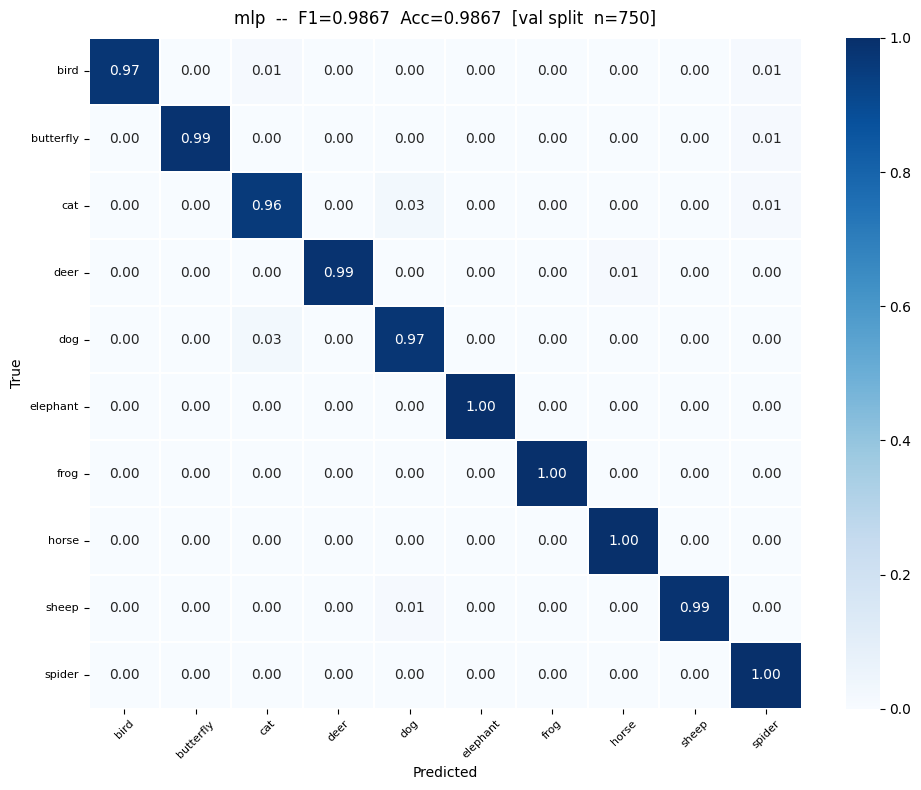


  PER-CLASS F1  (worst -> best)
  Class                               F1   Support
  ---------------------------------------------------
  cat                             0.9600        75
  dog                             0.9669        75
  spider                          0.9804        75
  bird                            0.9865        75
  butterfly                       0.9933        75
  deer                            0.9933        75
  sheep                           0.9933        75
  horse                           0.9934        75
  elephant                        1.0000        75
  frog                            1.0000        75

  Class: cat                           F1=0.9600  errors=3/75
  Confusion row  (total=75):
    OK  cat                            72x
    XX  dog                             2x
    XX  spider                          1x



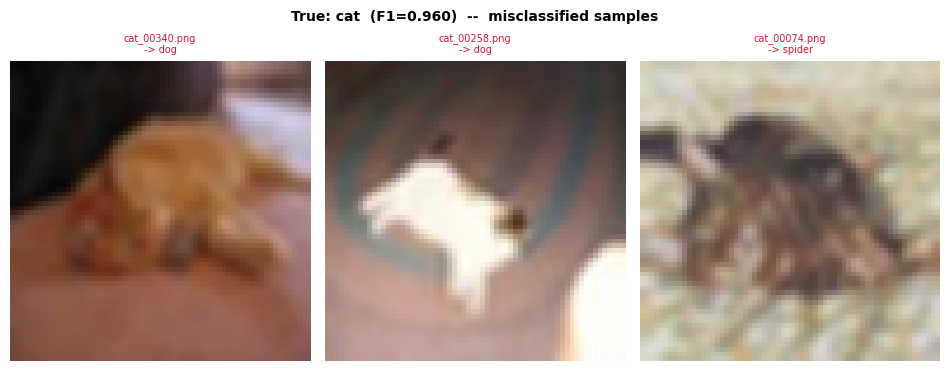


  Class: dog                           F1=0.9669  errors=2/75
  Confusion row  (total=75):
    OK  dog                            73x
    XX  cat                             2x



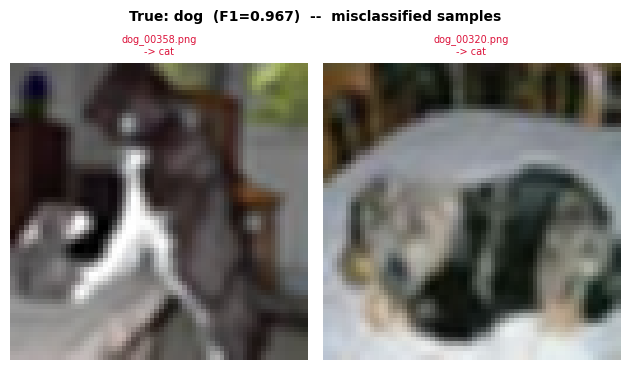


  Class: spider                        F1=0.9804  errors=0/75
  :)  Model got every sample in this class correct!

  Class: bird                          F1=0.9865  errors=2/75
  Confusion row  (total=75):
    OK  bird                           73x
    XX  spider                          1x
    XX  cat                             1x



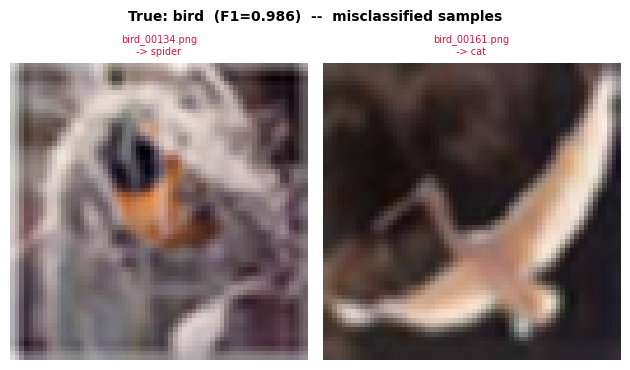


  Class: butterfly                     F1=0.9933  errors=1/75
  Confusion row  (total=75):
    OK  butterfly                      74x
    XX  spider                          1x



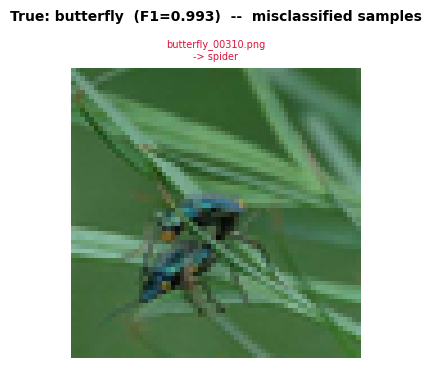


  Class: deer                          F1=0.9933  errors=1/75
  Confusion row  (total=75):
    OK  deer                           74x
    XX  horse                           1x



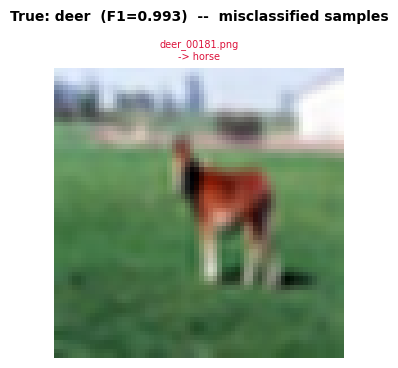


  Class: sheep                         F1=0.9933  errors=1/75
  Confusion row  (total=75):
    OK  sheep                          74x
    XX  dog                             1x



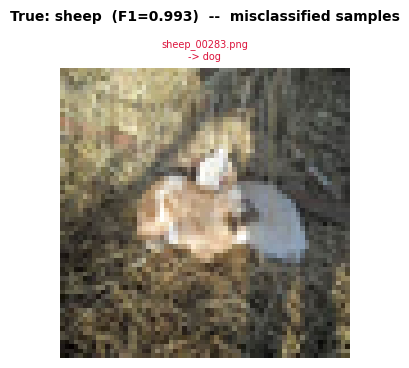


  Class: horse                         F1=0.9934  errors=0/75
  :)  Model got every sample in this class correct!

  Class: elephant                      F1=1.0000  errors=0/75
  :)  Model got every sample in this class correct!

  Class: frog                          F1=1.0000  errors=0/75
  :)  Model got every sample in this class correct!



In [26]:
# =============================================================================
# ERROR ANALYSIS
# =============================================================================

import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, classification_report

IMAGES_PER_CLASS = 10


if USE_FINETUNED:
    ea_path       = f'Data\\task1_data\\t1_train_features_ft{feat_suffix}.pt'
    ea_mode_label = 'Fine-tuned'
else:
    ea_path       = f'Data\\task1_data\\t1_train_features{feat_suffix}.pt'
    ea_mode_label = 'Frozen'

print(f'[error analysis] {ea_mode_label} features fit on train_idx_ft, eval on val_idx_ft')

ea_data          = torch.load(ea_path, weights_only=False)
ea_features_raw  = ea_data['features']
ea_labels_tensor = ea_data['labels']
ea_features      = np.asarray(ea_features_raw)
ea_labels_numpy  = ea_labels_tensor.numpy()
ea_labels        = np.asarray(ea_labels_numpy, dtype=np.int64)


class_to_index = train_data['class_to_index']

index_to_class = {}
for class_name, class_index in class_to_index.items():
    index_to_class[class_index] = class_name

class_names = []
for i in sorted(index_to_class):
    class_names.append(index_to_class[i])

n_classes         = len(class_names)
train_image_paths = train_data['paths']


def get_error_analysis_model():
    if SUBMISSION_MODEL == 'linear':
        return LogisticRegression(max_iter=2000, random_state=42)
    if SUBMISSION_MODEL == 'svm':
        return SVC(decision_function_shape='ovr', random_state=42, **SVM_SUBMISSION_PARAMS)
    if SUBMISSION_MODEL == 'knn':
        return KNeighborsClassifier(n_neighbors=KNN_NEIGHBOURS, metric=KNN_DISTANCE_METRIC, n_jobs=-1)
    if SUBMISSION_MODEL == 'mlp':
        mlp_params = {
            'type':       'mlp',
            'hidden':     MLP_SUBMISSION_HIDDEN_LAYERS,
            'dropout':    MLP_SUBMISSION_DROPOUT_RATE,
            'lr':         MLP_SUBMISSION_LEARNING_RATE,
            'activation': MLP_ACTIVATION,
        }
        return mlp_params
    raise ValueError(f'Unknown SUBMISSION_MODEL: {SUBMISSION_MODEL!r}')


model_cand = get_error_analysis_model()


def fit_predict(tr_i, va_i):

    fold_train_lbl = ea_labels[tr_i]
    fold_val_lbl   = ea_labels[va_i]

    is_mlp_dict = isinstance(model_cand, dict)
    is_mlp_type = is_mlp_dict and model_cand.get('type') == 'mlp'

    if is_mlp_type:
        p             = model_cand
        hidden_layers = p['hidden']
        activation_fn = p.get('activation', nn.ReLU)
        dropout_rate  = p.get('dropout',    0.0)
        learning_rate = p.get('lr',         1e-3)

        train_feats_float = ea_features[tr_i].astype(np.float32)
        val_feats_float   = ea_features[va_i].astype(np.float32)

        fold_model, throwaway_metrics = train_multilayer_perceptron(
            train_feats_float, fold_train_lbl,
            val_feats_float,   fold_val_lbl,
            hidden_layers = hidden_layers,
            activation    = activation_fn,
            dropout       = dropout_rate,
            learning_rate = learning_rate,
        )
        fold_model.eval()

        first_param = next(fold_model.parameters())
        dev         = first_param.device

        va_feats_float  = ea_features[va_i].astype(np.float32)
        va_feats_tensor = torch.tensor(va_feats_float)
        va_feats_device = va_feats_tensor.to(dev)

        with torch.no_grad():
            logits     = fold_model(va_feats_device)
            argmax     = logits.argmax(1)
            argmax_cpu = argmax.cpu()
            preds      = argmax_cpu.numpy()
    else:
        train_feats = np.asarray(ea_features[tr_i])
        train_lbls  = np.asarray(fold_train_lbl)
        val_feats   = np.asarray(ea_features[va_i])

        m = clone(model_cand)
        m.fit(train_feats, train_lbls)
        preds = m.predict(val_feats)

    return preds


# =============================================================================
# EVALUATION  (fit on train_idx_ft, evaluate on val_idx_ft)
# =============================================================================

print(f'Error analysis  model={SUBMISSION_MODEL}  (val split  n={len(val_idx_ft)})')

preds       = fit_predict(train_idx_ft, val_idx_ft)
eval_idx    = val_idx_ft
eval_labels = ea_labels[val_idx_ft]
eval_preds  = preds
split_label = f'val split  n={len(val_idx_ft)}'

oof_f1  = f1_score(eval_labels, eval_preds, average='weighted', zero_division=0)
oof_acc = accuracy_score(eval_labels, eval_preds)
print(f'  F1={oof_f1:.4f}  Acc={oof_acc:.4f}')


# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm       = confusion_matrix(eval_labels, eval_preds)
cm_float = cm.astype(float)
cm_sums  = cm.sum(axis=1, keepdims=True)
cm_norm  = cm_float / cm_sums

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, vmin=0, vmax=1, linewidths=0.3)

title_text = f'{SUBMISSION_MODEL}  --  F1={oof_f1:.4f}  Acc={oof_acc:.4f}  [{split_label}]'
ax.set_title(title_text, pad=10)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()


# =============================================================================
# PER-CLASS F1 TABLE
# =============================================================================

report = classification_report(eval_labels, eval_preds, target_names=class_names,
                                output_dict=True, zero_division=0)

class_f1s = []
for cls in class_names:
    cls_f1 = report[cls]['f1-score']
    class_f1s.append((cls, cls_f1))


def get_f1_value(item):
    return item[1]


class_f1s_sorted = sorted(class_f1s, key=get_f1_value)

print(f'\n{"="*55}')
print('  PER-CLASS F1  (worst -> best)')
print(f'{"="*55}')
print(f'  {"Class":<28}  {"F1":>8}  {"Support":>8}')
print(f'  {"-"*51}')

for cls, f1_val in class_f1s_sorted:
    supp = int(report[cls]['support'])
    print(f'  {cls:<28}  {f1_val:>8.4f}  {supp:>8}')

print()


# =============================================================================
# MISCLASSIFIED IMAGES PER CLASS  (worst first)
# =============================================================================

for cls, class_f1_val in class_f1s_sorted:

    class_idx   = class_to_index[cls]
    is_true_cls = eval_labels == class_idx
    is_wrong    = eval_preds  != class_idx
    wrong_mask  = is_true_cls & is_wrong
    wrong_pos   = np.where(wrong_mask)[0]

    print(f'{"="*78}')
    print(f'  Class: {cls:<28}  F1={class_f1_val:.4f}  '
          f'errors={len(wrong_pos)}/{int(report[cls]["support"])}')
    print(f'{"="*78}')

    if len(wrong_pos) == 0:
        print('  :)  Model got every sample in this class correct!\n')
        continue

    conf_row     = cm[class_idx]
    conf_row_sum = conf_row.sum()
    print(f'  Confusion row  (total={conf_row_sum}):')

    sorted_ascending  = np.argsort(conf_row)
    sorted_other_idxs = sorted_ascending[::-1]

    for other_idx in sorted_other_idxs:
        if conf_row[other_idx] == 0:
            continue
        if other_idx == class_idx:
            marker = 'OK'
        else:
            marker = 'XX'
        predicted_class = index_to_class[other_idx]
        count_val       = conf_row[other_idx]
        print(f'    {marker}  {predicted_class:<28}  {count_val:>3}x')
    print()

    show_pos = wrong_pos[:IMAGES_PER_CLASS]
    n_show   = len(show_pos)
    n_cols   = min(4, n_show)
    n_rows   = math.ceil(n_show / n_cols)

    fig_width  = 3.2 * n_cols
    fig_height = 3.2 * n_rows + 0.7

    fig_mc, axes_mc = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))

    title_text = f'True: {cls}  (F1={class_f1_val:.3f})  --  misclassified samples'
    fig_mc.suptitle(title_text, fontsize=10, fontweight='bold')

    if n_show > 1:
        axes_array = np.array(axes_mc)
        axes_flat  = axes_array.flatten()
    else:
        axes_flat = [axes_mc]

    for ax_img, pos in zip(axes_flat, show_pos):
        img_idx   = eval_idx[pos]
        pred_cls  = index_to_class[eval_preds[pos]]
        img_path  = train_image_paths[img_idx]
        img_name  = os.path.basename(img_path)
        pil_image = Image.open(img_path)
        title_str = f'{img_name}\n-> {pred_cls}'

        ax_img.imshow(pil_image)
        ax_img.set_title(title_str, fontsize=7, color='crimson')
        ax_img.axis('off')

    for ax_img in axes_flat[n_show:]:
        ax_img.axis('off')

    plt.tight_layout()
    plt.show()
    print()